## 4. Statistical Analysis

Following the exploratory data analysis (EDA), statistical methods were applied to formally evaluate the relationships between injury characteristics and hospital admission.

The analysis was designed to move from simple comparisons to multivariable modeling:

- **T-test** was used to examine whether admitted and non-admitted patients differ in mean age.
- **Chi-square tests** were conducted to assess associations between categorical variables and admission.
- **Logistic regression** was applied to evaluate the combined effect of multiple predictors on admission risk.

Hospital admission was treated as a binary outcome variable (1 = admitted, 0 = not admitted), with statistical significance evaluated at the 0.05 level.

Given the large sample size, emphasis was placed not only on statistical significance, but also on effect size and practical relevance.


## 4.0 Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

In [3]:
neiss_2024_analysis = pd.read_csv('../clean_data/neiss_2024_analysis.csv')

neiss_2024_analysis.head(2).T


,0,1
cpsc_case_number,240108461,240108462
treatment_date,2024-01-01,2024-01-01
age_year,16.0,56.0
sex,male,female
race,unknown,white
hispanic,yes,no
body_part,shoulder,finger
diagnosis,"strain, sprain",laceration
location,place of recreation or sports,home
fire_involvement,no_fire_or_not_recorded,no_fire_or_not_recorded


## 4.1 Numerical Hypothesis Test (T-test)

- Hypotheses

  - Null Hypothesis (H₀):
    There is no significant difference in the mean age between admitted and non-admitted patients. (μ_admitted = μ_not_admitted)

  - Alternative Hypothesis (H₁):
    There is a significant difference in the mean age between admitted and non-admitted patients. (μ_admitted ≠ μ_not_admitted)

- Significance Level: Set the significance level at α = 0.05.

- Check Conditions
  1. Independence:
    Each case represents a different patient → satisfied.
  2. Normality:
    Age distribution within both groups should be approximately normal → Visualized using histograms.
  3. Sample Size:
    Both groups have large sample sizes, so the Central Limit Theorem applies.

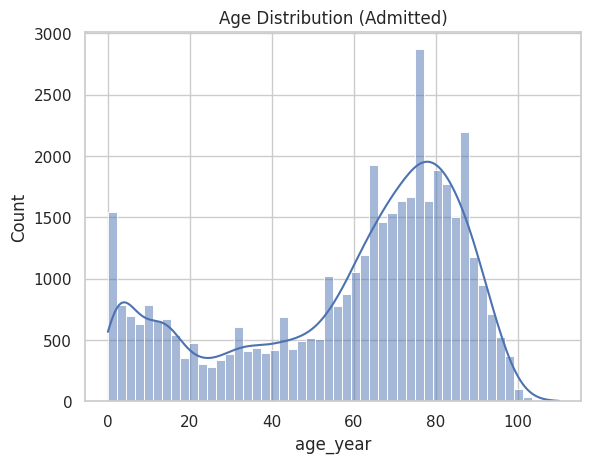

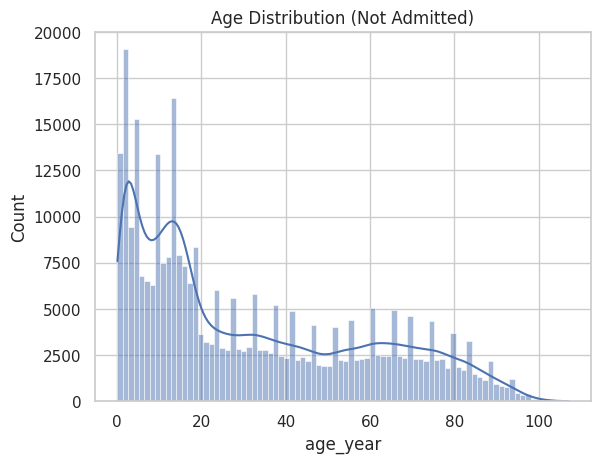

,age_year
admitted,
0,319073
1,42212


In [4]:
# admitted
sns.histplot(neiss_2024_analysis[neiss_2024_analysis['admitted']==1]['age_year'], kde=True)
plt.title("Age Distribution (Admitted)")
plt.show()

# not admitted
sns.histplot(neiss_2024_analysis[neiss_2024_analysis['admitted']==0]['age_year'], kde=True)
plt.title("Age Distribution (Not Admitted)")
plt.show()

# sample size
neiss_2024_analysis.groupby('admitted')['age_year'].count()

In [5]:
admitted_age = neiss_2024_analysis[neiss_2024_analysis['admitted'] == 1]['age_year']
not_admitted_age = neiss_2024_analysis[neiss_2024_analysis['admitted'] == 0]['age_year']

t_stat, p_value = ttest_ind(admitted_age, not_admitted_age, equal_var=False)

# We will compare the p-value to the significance level (α = 0.05) to determine whether to reject or fail to reject the null hypothesis.
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis (H₀).")
    print("There is a significant difference in the mean age between admitted and non-admitted patients.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis (H₀).")
    print("There is no significant difference in the mean age between admitted and non-admitted patients.")

t-statistic: 191.2996
p-value: 0.0000
Since the p-value is less than 0.05, we reject the null hypothesis (H₀).
There is a significant difference in the mean age between admitted and non-admitted patients.


In [6]:
pooled_std = np.sqrt(
    ((admitted_age.std() ** 2) + (not_admitted_age.std() ** 2)) / 2
)

diff = admitted_age.mean() - not_admitted_age.mean()

cohens_d = diff / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")


Cohen's d: 1.003


## 4.2 Categorical Hypothesis Test (Chi-square)

- Hypotheses

  - Null Hypothesis (H₀):

    Each of the selected features (body_part, diagnosis, fire_involvement, age_group, location) is independent of hospital admission. There is no association between each feature and hospital admission.

  - Alternative Hypothesis (H₁):

    Each of the selected features (body_part, diagnosis, fire_involvement, age_group, location) is associated with hospital admission. There is a significant relationship between each feature and hospital admission.

- Significance Level:  Set the significance level at α = 0.05.

- Check Conditions
  
  - Independence:
  
    Each observation represents a different case → satisfied.
  
  - Expected Frequency:
  
    Expected counts in each cell should be ≥ 5 → Verified using chi-square expected values.

In [7]:
def cramers_v(confusion_matrix):

    chi2, _, _, _ = chi2_contingency(confusion_matrix)

    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

In [8]:
results = []

variables = [
    'body_part',
    'diagnosis',
    'fire_involvement',
    'age_group',
    'location'
]

for var in variables:

    table = pd.crosstab(neiss_2024_analysis[var], neiss_2024_analysis['admitted'])

    chi2, p, dof, expected = chi2_contingency(table)

    v = cramers_v(table)

    results.append({
        "Variable": var,
        "Chi-square": round(chi2, 2),
        "p-value": "<0.001" if p < 0.001 else round(p, 4),
        "Cramers_V": round(v, 3),
        "Min Expected Count": round(expected.min(), 2),
        "Condition Met (>=5)": expected.min() >= 5,
        "Reject H0": p < 0.05
    })

chi_square_summary = pd.DataFrame(results)

chi_square_summary.sort_values(by='Cramers_V', ascending=False)


,Variable,Chi-square,p-value,Cramers_V,Min Expected Count,Condition Met (>=5),Reject H0
3,age_group,37447.67,<0.001,0.322,1154.83,True,True
0,body_part,25508.89,<0.001,0.266,2.45,False,True
1,diagnosis,23467.52,<0.001,0.255,10.28,True,True
4,location,7171.76,<0.001,0.141,5.37,True,True
2,fire_involvement,1064.90,<0.001,0.054,41.59,True,True


- Chi-square tests showed that p-value < 0.05 for all variables, we reject the null hypothesis for each of the five features. There is a significant association between each of the features (body_part, diagnosis, fire_involvement, age_group, location) and hospital admission.

- However, given the large sample size, effect sizes (Cramér’s V) were used to better assess the strength of these relationships.

- Age group exhibited the strongest association with admission (Cramér’s V = 0.322), followed by body part (0.266) and diagnosis (0.255), indicating moderate relationships. In contrast, injury location showed a weaker association (0.141), while fire involvement had a very small effect size (0.054).

- These results indicate that age and injury charateristics are the primary drivers of hospital admission, while fire involvement contributes relatively little when considered alone.

## 4.3 Logistic Regression

In [9]:
model = smf.logit(
    "admitted ~ C(age_group) + C(fire_involvement) + C(location)",
    data=neiss_2024_analysis
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.311770
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               admitted   No. Observations:               361285
Model:                          Logit   Df Residuals:                   361266
Method:                           MLE   Df Model:                           18
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.1354
Time:                        07:45:55   Log-Likelihood:            -1.1264e+05
converged:                       True   LL-Null:                   -1.3027e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                           

In [10]:
np.exp(model.params)
np.exp(model.conf_int())

,0,1
Intercept,0.374393,1.036357
C(age_group)[T.child (5-12)],0.987622,1.121020
C(age_group)[T.elderly (65+)],8.812477,9.816499
C(age_group)[T.infant (<1)],1.105269,1.351375
C(age_group)[T.mid adult (35-49)],1.937725,2.192310
C(age_group)[T.older adult (50-64)],3.792261,4.252750
C(age_group)[T.toddler (1-4)],0.886520,1.018895
C(age_group)[T.young adult (18-34)],1.158819,1.312360
C(fire_involvement)[T.fire_fd_not_attended],0.351873,0.667910
C(fire_involvement)[T.fire_fd_unknown],0.655957,1.051175


In [11]:
odds_ratios = np.exp(model.params)

sorted_odds_ratios = odds_ratios.sort_values(ascending=False)

print(sorted_odds_ratios)

C(age_group)[T.elderly (65+)]                     9.300950
C(age_group)[T.older adult (50-64)]               4.015911
C(age_group)[T.mid adult (35-49)]                 2.061090
C(age_group)[T.young adult (18-34)]               1.233202
C(age_group)[T.infant (<1)]                       1.222143
C(age_group)[T.child (5-12)]                      1.052209
C(age_group)[T.toddler (1-4)]                     0.950406
C(location)[T.street or highway]                  0.871544
C(fire_involvement)[T.fire_fd_unknown]            0.830377
C(location)[T.mobile/manufactured home]           0.691280
Intercept                                         0.622900
C(fire_involvement)[T.fire_fd_not_attended]       0.484788
C(location)[T.home]                               0.468451
C(location)[T.other public property]              0.416608
C(location)[T.unknown]                            0.362728
C(location)[T.place of recreation or sports]      0.322325
C(location)[T.school/daycare]                     0.2723

- A logistic regression model was used to examine the combined effects of age group, fire involvement, and injury location on hospital admission.

- The model was statistically significant (LLR p < 0.001) with a pseudo R² of 0.135, indicating moderate explanatory power.

- Age was the strongest predictor. Elderly patients (65+) had approximately 9.3 times higher odds of admission, followed by older adults (50–64) (OR ≈ 4.0) and middle-aged adults (35–49) (OR ≈ 2.1).

- Fire involvement showed a weaker and less consistent effect. Non-fire incidents had substantially lower odds of admission (OR ≈ 0.18), but some fire-related categories were not statistically significant.

- Injury location had a smaller impact overall, with most locations associated with lower odds compared to the reference group.

- Overall, age remains the dominant predictor, while other factors provide additional but more limited explanatory value.

## 4.4 Overall

Across all statistical methods, consistent patterns emerged regarding the factors associated with hospital admission.

Age was identified as the most influential factor. Both hypothesis testing and logistic regression showed that older patients, particularly those aged 65 and above, have substantially higher admission risk.

Injury characteristics, including body part affected and diagnosis type, also demonstrated meaningful associations with admission. These factors likely reflect underlying injury severity.

Contextual variables, such as fire involvement and location, showed statistically significant relationships with admission; however, their effect sizes were comparatively smaller, indicating a more limited practical impact when considered independently.

Importantly, due to the large sample size, many variables were found to be statistically significant. Therefore, interpretation focused on effect size and real-world relevance rather than p-values alone.

Overall, the results suggest that hospital admission is primarily driven by **patient age and injury severity**, while other factors provide additional but secondary explanatory value.
